#Experiment 8

### Build an Encoder and Decoder Architecture for a Variational Autoencoder (VAE) using a Deep Learning Framework

In [1]:
# Import Libraries

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import mnist

In [2]:
(X_train, _), (X_test, _) = mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = np.reshape(X_train, (-1, 28, 28, 1))
X_test = np.reshape(X_test, (-1, 28, 28, 1))

print(X_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28, 1)


In [3]:
latent_dim = 2
encoder_inputs = layers.Input(shape=(28,28,1))

x = layers.Flatten()(encoder_inputs)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(128, activation='relu')(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

In [4]:
def sampling(args):

    z_mean, z_log_var = args

    epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0], latent_dim))

    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling, name="z")([z_mean, z_log_var])

In [5]:
# create encoder model
encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 784)       │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    200,960 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        258 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        258 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Lambda)          │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 234,372 (915.52 KB)

 Trainable params: 234,372 (915.52 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
latent_inputs = layers.Input(shape=(latent_dim,))

x = layers.Dense(128, activation='relu')(latent_inputs)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(28*28, activation='sigmoid')(x)

decoder_outputs = layers.Reshape((28,28,1))(x)

In [7]:
# create decoder model
decoder = Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       201,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 234,896 (917.56 KB)

 Trainable params: 234,896 (917.56 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
#VAE
outputs = decoder(encoder(encoder_inputs)[2])

vae = Model(encoder_inputs, outputs, name="vae")

In [14]:
class VAE(tf.keras.Model):

    def __init__(self, encoder, decoder):
        super(VAE, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):

        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)

        return reconstruction

    def train_step(self, data):

        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:

            z_mean, z_log_var, z = self.encoder(data)

            reconstruction = self.decoder(z)

            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1,2)
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss
        }

In [15]:
# create model
vae = VAE(encoder, decoder)
vae.compile(optimizer='adam')

In [17]:
# train model
history = vae.fit(
    X_train,
    epochs=10,
    batch_size=128
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - kl_loss: 5.0199 - loss: 168.6206 - reconstruction_loss: 163.6008
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - kl_loss: 5.3601 - loss: 148.0208 - reconstruction_loss: 142.6606
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - kl_loss: 5.3208 - loss: 158.2358 - reconstruction_loss: 152.9150
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - kl_loss: 5.5514 - loss: 157.2980 - reconstruction_loss: 151.7466
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - kl_loss: 5.8938 - loss: 141.6929 - reconstruction_loss: 135.7991
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 30ms/step - kl_loss: 5.9397 - loss: 138.9479 - reconstruction_loss: 133.0082
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - kl_loss: 5.7956 - loss: 148.9679 - reconstruction_loss: 143.1723
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - kl_loss: 6.1917 - loss: 158.0502 - reconstruction_loss: 151.8585
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━

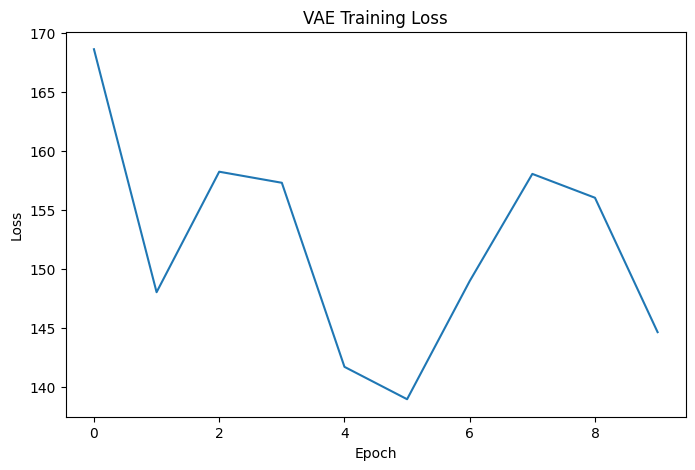

In [18]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])

plt.title("VAE Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [19]:
# Encode test image
z_mean, z_log_var, z = encoder.predict(X_test[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


In [20]:
# reconstruct images
reconstructed = decoder.predict(z)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


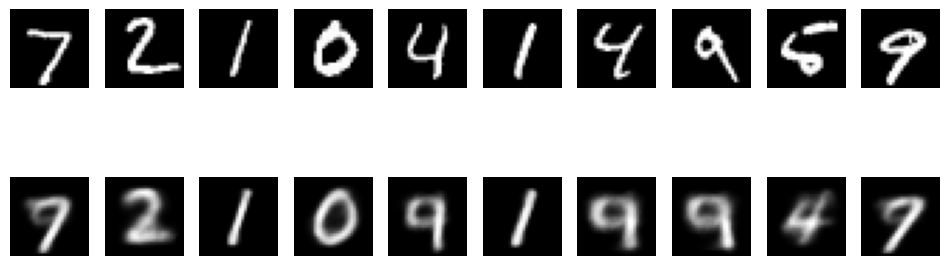

In [21]:
plt.figure(figsize=(12,4))

for i in range(10):

    # Original Images
    plt.subplot(2,10,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    # Reconstructed Images
    plt.subplot(2,10,i+11)
    plt.imshow(reconstructed[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


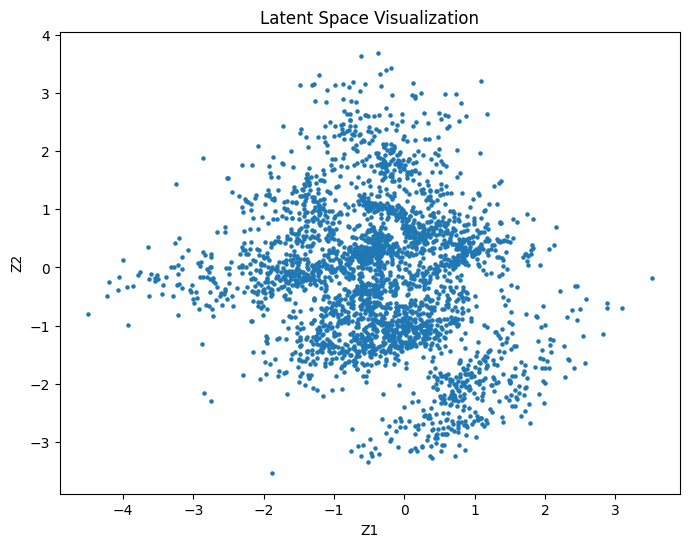

In [22]:
# Visualize Latent Space
z_mean, _, _ = encoder.predict(X_test[:3000])

plt.figure(figsize=(8,6))
plt.scatter(z_mean[:,0], z_mean[:,1], s=5)

plt.title("Latent Space Visualization")
plt.xlabel("Z1")
plt.ylabel("Z2")
plt.show()

In [23]:
# Generate new digits
random_points = np.random.normal(size=(10,2))
generated = decoder.predict(random_points)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


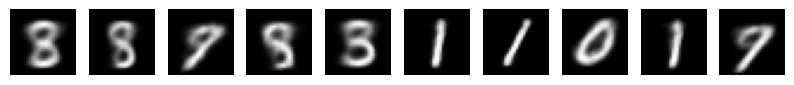

In [24]:
# Show generated image
plt.figure(figsize=(10,2))

for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(generated[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

## Result

Successfully trained a Variational Autoencoder (VAE) on MNIST dataset.
The encoder learned latent representations, decoder reconstructed input images,
and new handwritten digit images were generated from latent space.